# Сравнение стратегий задачи о назначениях



In [28]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import time
import matplotlib.pyplot as plt


## Генерация данных

Матрица **C** (в коде: `A`): элемент `cᵢⱼ` — потенциальная прибыль группы `i` в период `j`.

Вектор **χ** длиной `n`: коэффициент уязвимости группы `i`, `0 < χᵢ < 1`.

Матрица **B**:

```
bᵢⱼ = (1 − χᵢ) · Σ_{t=j}^{n} cᵢₜ,   i, j = 1, …, n
```


In [29]:
def build_B_matrix(A, chi):
    """Формула документа (§3): bᵢⱼ = (1 − χᵢ) · Σ_{t=j}^{n} cᵢₜ  (индексация с 1).
    В коде (0-индексация): B[i][j] = (1 - chi[i]) * sum(A[i][t] for t in range(j, n))."""
    n = A.shape[0]
    B = np.zeros((n, n))
    for i in range(n):
        suffix = np.zeros(n)
        suffix[n - 1] = A[i][n - 1]
        for t in range(n - 2, -1, -1):
            suffix[t] = suffix[t + 1] + A[i][t]
        for j in range(n):
            B[i][j] = (1 - chi[i]) * suffix[j]
    return B

def calculate_total_profit(A, chi, B, schedule):
    """Целевая функция: базовая прибыль + бонус за защиту."""
    base = np.sum(chi[:, np.newaxis] * A)
    bonus = sum(B[schedule[j]][j] for j in range(A.shape[0]))
    return base + bonus

def generate_A_descending(n, low=1, high=10):
    A = np.zeros((n, n))
    for i in range(n):
        row = np.random.uniform(low, high, n)
        row.sort()
        A[i] = row[::-1]
    return A

def generate_A_ascending(n, low=1, high=10):
    A = np.zeros((n, n))
    for i in range(n):
        row = np.random.uniform(low, high, n)
        row.sort()
        A[i] = row
    return A

def generate_A_random(n, low=1, high=10):
    return np.random.uniform(low, high, (n, n))

def generate_chi(n, low=0.3, high=0.8):
    return np.random.uniform(low, high, n)


## Стратегии

Все стратегии принимают **полную матрицу A** и вектор **χ**.
Это соответствует экспериментальной постановке из документа:
матрица сгенерирована заранее, стратегии соревнуются по итоговой прибыли.

- **Жадная** — на каждом шаге выбирает `argmax B[i][j]` среди свободных групп.
  Требует полного знания B (и, следовательно, всей A). Описана в документе как
  основная эвристика для сравнения.
- **χ-стратегия** — сортировка по возрастанию χᵢ. Решение не зависит от A.
- **Венгерский алгоритм** — оптимальное назначение на полной матрице B.
  Используется как  эталон.
- **Гибрид-1 / Гибрид-2** — чередование жадного и χ-шагов.
- **Ансамбль-жадный / Ансамбль-χ** — несколько агентов с случайной выборкой кандидатов;
  побеждает агент с наибольшей итоговой прибылью.
- **Half-Hybrid** — первые `(n/2)` шагов: χ-стратегия (min χᵢ); оставшиеся: жадный алгоритм.
- **Half-Hybrid 2** — первые `(n/2)` шагов: жадная стратегия; оставшиеся: χ-стратегия (min χᵢ).

In [30]:
def greedy_strategy(A, chi):
    """argmax B[i][j] на каждом шаге. Требует знания полной матрицы A."""
    B = build_B_matrix(A, chi)
    n = A.shape[0]
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        best_i = max(available, key=lambda i: B[i][j])
        schedule.append(best_i)
        used.add(best_i)
    return schedule

def chi_strategy(A, chi):
    """Сортировка по возрастанию chi. Матрица A не используется."""
    return list(np.argsort(chi))

def hungarian_strategy(A, chi):
    """Оптимальное решение на полной B (пост-фактум эталон)."""
    B = build_B_matrix(A, chi)
    row_ind, col_ind = linear_sum_assignment(-B)
    schedule = [-1] * A.shape[0]
    for i, j in zip(row_ind, col_ind):
        schedule[j] = i
    return schedule

def hybrid_strategy(A, chi):
    """Чётные шаги: min chi; нечётные: argmax B[i][j]."""
    B = build_B_matrix(A, chi)
    n = A.shape[0]
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        if j % 2 == 0:
            best_i = min(available, key=lambda i: chi[i])
        else:
            best_i = max(available, key=lambda i: B[i][j])
        schedule.append(best_i)
        used.add(best_i)
    return schedule

def hybrid_strategy2(A, chi):
    """Чётные шаги: argmax B[i][j]; нечётные: min chi."""
    B = build_B_matrix(A, chi)
    n = A.shape[0]
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        if j % 2 == 0:
            best_i = max(available, key=lambda i: B[i][j])
        else:
            best_i = min(available, key=lambda i: chi[i])
        schedule.append(best_i)
        used.add(best_i)
    return schedule

def half_hybrid(A, chi):
    """Первые ceil(n/2) шагов: min chi (χ-стратегия).
    Оставшиеся шаги: argmax (1-chi[i])*A[i][j] (онлайн-жадная по текущему столбцу).
    Логика: ранние периоды дают длинный хвост суммы в B — отдаём их самым уязвимым.
    Поздние периоды оцениваем по реальному столбцу A, доступному в этот момент."""
    import math
    n = A.shape[0]
    half = math.ceil(n / 2)
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        if j < half:
            best_i = min(available, key=lambda i: chi[i])
        else:
            best_i = max(available, key=lambda i: (1 - chi[i]) * A[i][j])
        schedule.append(best_i)
        used.add(best_i)
    return schedule


def half_hybrid2(A, chi):
    """Первые ceil(n/2) шагов: argmax (1-chi[i])*A[i][j] (онлайн-жадная).
    Оставшиеся шаги: min chi (χ-стратегия).
    Зеркальный вариант half_hybrid."""
    import math
    n = A.shape[0]
    half = math.ceil(n / 2)
    used = set()
    schedule = []
    for j in range(n):
        available = [i for i in range(n) if i not in used]
        if j < half:
            best_i = max(available, key=lambda i: (1 - chi[i]) * A[i][j])
        else:
            best_i = min(available, key=lambda i: chi[i])
        schedule.append(best_i)
        used.add(best_i)
    return schedule


In [31]:
# greedy_strategy выбирает argmax B[i][j] среди ВСЕХ свободных групп — результат всегда один и тот же.
# ensemble_strategy запускает num_models копий жадного, но каждый видит только случайные ss кандидатов
# разные агенты строят разные расписания → берём лучшее (аналог Random Forest с деревьями).

def ensemble_strategy(A, chi, num_models=10, sample_size=None):
    B  = build_B_matrix(A, chi)
    n  = A.shape[0]
    ss = sample_size if sample_size is not None else max(1, n // 3)

    schedules = [[-1] * n for agent in range(num_models)]
    used      = [set()    for agent in range(num_models)]
    rngs      = [np.random.default_rng(seed=agent) for agent in range(num_models)]

    for j in range(n):
        for agent in range(num_models):

            # собираем все свободные группы этого агента
            available = []
            for i in range(n):
                if i not in used[agent]:
                    available.append(i)

            # случайно берём ss из них — источник разнообразия между агентами
            k = min(ss, len(available))
            candidates = rngs[agent].choice(available, size=k, replace=False)

            # жадный выбор — argmax B[i][j], но только среди candidates
            best_i = candidates[0]
            for i in candidates:
                if B[i][j] > B[best_i][j]:
                    best_i = i

            schedules[agent][j] = best_i
            used[agent].add(best_i)

    # выбирается — агент с максимальной итоговой прибылью
    best_agent = 0
    for agent in range(1, num_models):
        if calculate_total_profit(A, chi, B, schedules[agent]) > \
           calculate_total_profit(A, chi, B, schedules[best_agent]):
            best_agent = agent

    return schedules[best_agent]

def ensemble_chi_strategy(A, chi, num_models=10, sample_size=None):
    B  = build_B_matrix(A, chi)
    n  = len(chi)
    ss = sample_size if sample_size is not None else max(1, n // 3)

    schedules = [[-1] * n for agent in range(num_models)]
    used      = [set()    for agent in range(num_models)]
    rngs      = [np.random.default_rng(seed=agent) for agent in range(num_models)]

    for j in range(n):
        for agent in range(num_models):

            available = []
            for i in range(n):
                if i not in used[agent]:
                    available.append(i)

            k = min(ss, len(available))
            candidates = rngs[agent].choice(available, size=k, replace=False)

            # жадный выбор — min chi[i], но только среди candidates
            best_i = candidates[0]
            for i in candidates:
                if chi[i] < chi[best_i]:
                    best_i = i

            schedules[agent][j] = best_i
            used[agent].add(best_i)

    best_agent = 0
    for agent in range(1, num_models):
        if calculate_total_profit(A, chi, B, schedules[agent]) > \
           calculate_total_profit(A, chi, B, schedules[best_agent]):
            best_agent = agent

    return schedules[best_agent]


In [32]:
def run_single_experiment(A_generator, n=10, a_low=1, a_high=10,
                          chi_low=0.3, chi_high=0.8,
                          num_models=10, sample_size=None):
    """Запускает один эксперимент: генерирует данные и применяет все стратегии"""
    # Генерируем данные
    A = A_generator(n, a_low, a_high)
    chi = generate_chi(n, chi_low, chi_high)
    B = build_B_matrix(A, chi)
    
    results = {}
    
    # Жадная стратегия
    t0 = time.time()
    sched = greedy_strategy(A, chi)
    t1 = time.time()
    results['greedy'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # χ-стратегия
    t0 = time.time()
    sched = chi_strategy(A, chi)
    t1 = time.time()
    results['chi'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Венгерский алгоритм
    t0 = time.time()
    sched = hungarian_strategy(A, chi)
    t1 = time.time()
    results['hungarian'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Гибридная стратегия
    t0 = time.time()
    sched = hybrid_strategy(A, chi)
    t1 = time.time()
    results['hybrid'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Гибридная 2
    t0 = time.time()
    sched = hybrid_strategy2(A, chi)
    t1 = time.time()
    results['hybrid2'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Ансамбль жадных
    t0 = time.time()
    sched = ensemble_strategy(A, chi, num_models, sample_size)
    t1 = time.time()
    results['ensemble'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Ансамбль χ
    t0 = time.time()
    sched = ensemble_chi_strategy(A, chi, num_models, sample_size)
    t1 = time.time()
    results['ensemble_chi'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Half-Hybrid
    t0 = time.time()
    sched = half_hybrid(A, chi)
    t1 = time.time()
    results['half_hybrid'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    # Half-Hybrid 2
    t0 = time.time()
    sched = half_hybrid2(A, chi)
    t1 = time.time()
    results['half_hybrid2'] = {
        'schedule': sched,
        'time': t1 - t0,
        'profit': calculate_total_profit(A, chi, B, sched)
    }
    
    return results


def run_series(A_generator, series_name, num_experiments=30, n=10,
               num_models=10, sample_size=None):
    """Запускает серию экспериментов и выводит статистику"""
    print('\n' + '=' * 70)
    print('Серия:', series_name)
    print('=' * 70)
    
    # Список всех стратегий
    strategies = ['greedy', 'chi', 'hungarian', 'hybrid', 'hybrid2',
                  'ensemble', 'ensemble_chi', 'half_hybrid', 'half_hybrid2']
    
    # Собираем результаты
    profits = {s: [] for s in strategies}
    times = {s: [] for s in strategies}
    
    # Запускаем эксперименты
    for exp_num in range(num_experiments):
        res = run_single_experiment(A_generator, n=n,
                                    num_models=num_models,
                                    sample_size=sample_size)
        for s in strategies:
            profits[s].append(res[s]['profit'])
            times[s].append(res[s]['time'])
    
    # Считаем средние
    max_avg = sum(profits['hungarian']) / len(profits['hungarian'])
    min_avg = sum(profits['chi']) / len(profits['chi'])
    gap = max(max_avg - min_avg, 0.000000001)
    
    # Выводим заголовок
    print(f"{'Стратегия':<14} {'Ср.прибыль':<12} {'Ср.время':<10} {'Отн.потери':<12} {'Норм.эфф.':<12} {'Худш.потери':<12}")
    print('-' * 74)
    
    # Выводим результаты для каждой стратегии
    for s in strategies:
        avg_profit = sum(profits[s]) / len(profits[s])
        avg_time = sum(times[s]) / len(times[s])
        
        # Относительные потери (относительно венгерского)
        if s == 'hungarian':
            loss = 0.0
        else:
            loss = (max_avg - avg_profit) / max_avg * 100
        
        # Нормированная эффективность
        eff = (avg_profit - min_avg) / gap * 100
        
        # Худший случай (минимальная прибыль)
        worst_profit = min(profits[s])
        worst_loss = (max_avg - worst_profit) / max_avg * 100
        
        print(f"{s:<14} {avg_profit:>10.2f} {avg_time:>8.4f}s {loss:>10.2f}% {eff:>10.1f}% {worst_loss:>10.2f}%")
    
    print(f"\n  Верхняя граница (Венгерский): {max_avg:.2f}")
    print(f"  Нижняя граница (chi-стратегия): {min_avg:.2f}")
    
    stats = {}
    for s in strategies:
        avg_p = sum(profits[s]) / len(profits[s])
        if s == 'hungarian':
            loss = 0.0
        else:
            loss = (max_avg - avg_p) / max_avg * 100
        stats[s] = {
            'avg_profit': avg_p,
            'loss':       loss,
            'times':      times[s],
        }
    return stats

## Запуск экспериментов

In [39]:
N           = 50   # размер матрицы (n×n групп и периодов)
NUM_EXP     = 50   # количество независимых экспериментов в каждой серии
NUM_MODELS  = 20   # количество агентов в ансамбле (аналог числа деревьев в Random Forest)
SAMPLE_SIZE = N // 3  # размер случайной выборки кандидатов для каждого агента

series = [
    ('Убывание',    generate_A_descending),
    ('Возрастание', generate_A_ascending),
    ('Случайная',   generate_A_random),
]

all_stats = {}
for series_name, generator in series:
    all_stats[series_name] = run_series(
        generator, series_name, NUM_EXP, n=N,
        num_models=NUM_MODELS, sample_size=SAMPLE_SIZE
    )



Серия: Убывание
Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           10490.99   0.0026s       0.14%       37.1%       4.61%
chi              10482.22   0.0000s       0.22%        0.0%       4.81%
hungarian        10505.84   0.0023s       0.00%      100.0%       4.54%
hybrid           10490.08   0.0025s       0.15%       33.3%       4.72%
hybrid2          10490.23   0.0025s       0.15%       33.9%       4.72%
ensemble         10492.62   0.0451s       0.13%       44.0%       4.61%
ensemble_chi     10482.26   0.0415s       0.22%        0.2%       4.80%
half_hybrid      10491.08   0.0005s       0.14%       37.5%       4.75%
half_hybrid2     10496.02   0.0006s       0.09%       58.4%       4.63%

  Верхняя граница (Венгерский): 10505.84
  Нижняя граница (chi-стратегия): 10482.22

Серия: Возрастание
Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 

Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           10457.76   0.0017s       0.14%       34.9%       5.71%
chi              10449.68   0.0000s       0.22%        0.0%       5.78%
hungarian        10472.84   0.0015s       0.00%      100.0%       5.45%
hybrid           10457.62   0.0017s       0.15%       34.3%       5.66%
hybrid2          10457.76   0.0017s       0.14%       34.9%       5.65%
ensemble         10459.16   0.0177s       0.13%       40.9%       5.67%
ensemble_chi     10449.69   0.0152s       0.22%        0.0%       5.76%
half_hybrid      10457.84   0.0003s       0.14%       35.2%       5.70%
half_hybrid2     10463.66   0.0004s       0.09%       60.3%       5.54%

  Верхняя граница (Венгерский): 10472.84
  Нижняя граница (chi-стратегия): 10449.68

Серия: Возрастание


Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           12093.67   0.0017s       0.14%       44.0%       3.05%
chi              12080.08   0.0000s       0.26%        0.0%       3.23%
hungarian        12110.98   0.0015s       0.00%      100.0%       2.90%
hybrid           12087.61   0.0017s       0.19%       24.4%       3.10%
hybrid2          12087.56   0.0017s       0.19%       24.2%       3.11%
ensemble         12096.85   0.0182s       0.12%       54.3%       3.03%
ensemble_chi     12083.71   0.0152s       0.23%       11.7%       3.19%
half_hybrid      12085.82   0.0003s       0.21%       18.6%       3.17%
half_hybrid2     12104.87   0.0004s       0.05%       80.2%       2.98%

  Верхняя граница (Венгерский): 12110.98
  Нижняя граница (chi-стратегия): 12080.08

Серия: Случайная


Стратегия      Ср.прибыль   Ср.время   Отн.потери   Норм.эфф.    Худш.потери 
--------------------------------------------------------------------------
greedy           11310.00   0.0017s       0.78%       21.4%       4.77%
chi              11285.75   0.0000s       1.00%        0.0%       5.05%
hungarian        11399.28   0.0016s       0.00%      100.0%       3.92%
hybrid           11298.98   0.0017s       0.88%       11.7%       4.82%
hybrid2          11298.76   0.0016s       0.88%       11.5%       5.04%
ensemble         11319.94   0.0177s       0.70%       30.1%       4.67%
ensemble_chi     11296.69   0.0152s       0.90%        9.6%       4.81%
half_hybrid      11301.83   0.0003s       0.85%       14.2%       4.84%
half_hybrid2     11313.76   0.0004s       0.75%       24.7%       4.73%

  Верхняя граница (Венгерский): 11399.28
  Нижняя граница (chi-стратегия): 11285.75


## Визуализация результатов

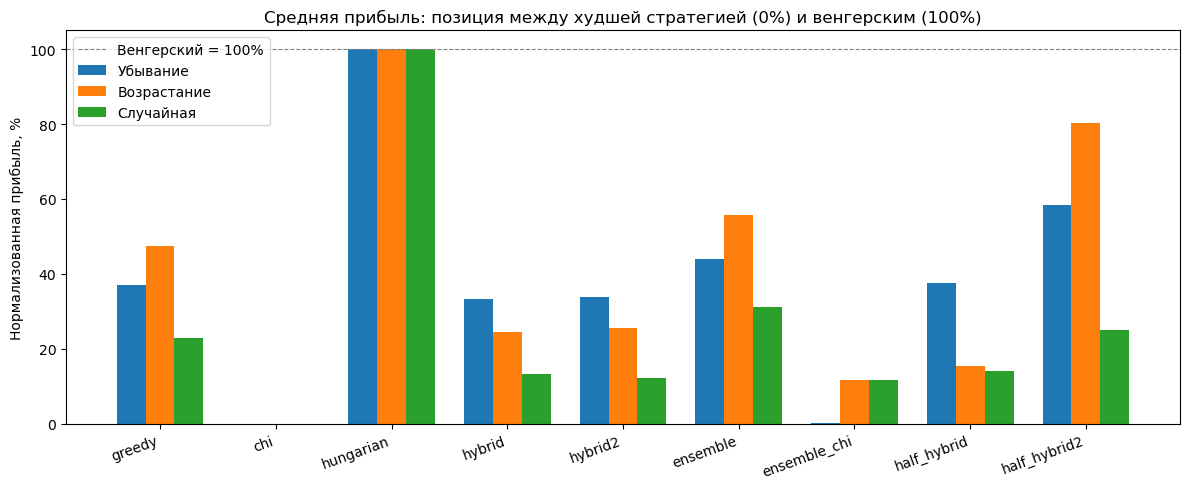

In [40]:
# Нормализованная прибыль относительно венгерского алгоритма:
#   score(s) = (avg(s) - min_серии) / (avg(hungarian) - min_серии) * 100%
# Венгерский = 100% (верхняя граница, всегда).
# Фактически худшая стратегия в серии = 0% (нижняя граница, любая).
# χ-стратегия не фиксирована на 0 — она может оказаться выше если не худшая.
strat_labels = ['greedy', 'chi', 'hungarian', 'hybrid', 'hybrid2',
                'ensemble', 'ensemble_chi', 'half_hybrid', 'half_hybrid2']
series_names = list(all_stats.keys())
x = np.arange(len(strat_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for k, sname in enumerate(series_names):
    avgs       = {s: all_stats[sname][s]['avg_profit'] for s in strat_labels}
    hun_avg    = avgs['hungarian']
    series_min = min(avgs.values())
    gap        = hun_avg - series_min
    vals = [(avgs[s] - series_min) / gap * 100 if gap > 1e-9 else 0.0
            for s in strat_labels]
    ax.bar(x + k * width, vals, width, label=sname)

ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', label='Венгерский = 100%')
ax.set_xticks(x + width)
ax.set_xticklabels(strat_labels, rotation=20, ha='right')
ax.set_ylabel('Нормализованная прибыль, %')
ax.set_title('Средняя прибыль: позиция между худшей стратегией (0%) и венгерским (100%)')
ax.legend()
plt.tight_layout()
plt.show()


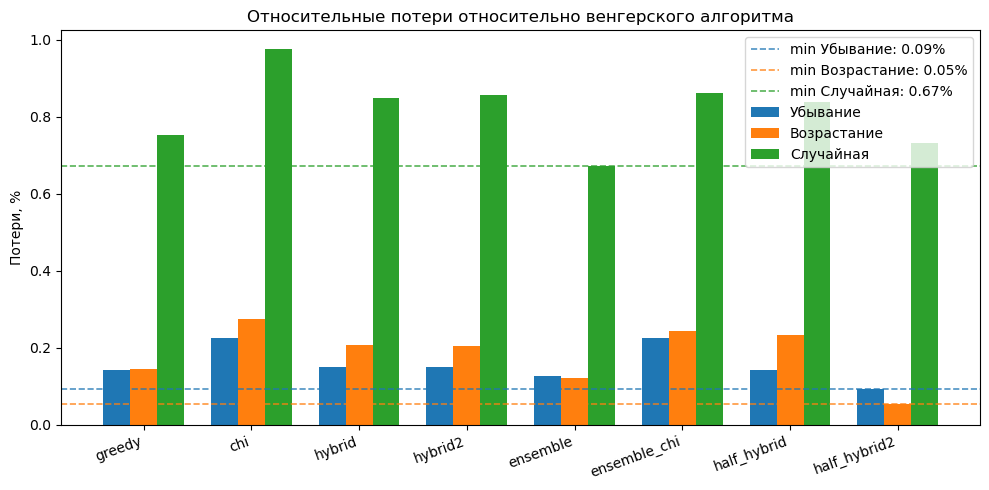

In [41]:
# Относительные потери (%) относительно венгерского алгоритма
non_hun = [s for s in strat_labels if s != 'hungarian']
x2 = np.arange(len(non_hun))

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = []
for k, sname in enumerate(series_names):
    vals = [all_stats[sname][s]['loss'] for s in non_hun]
    bars = ax.bar(x2 + k * width, vals, width, label=sname)
    bar_colors.append(bars[0].get_facecolor())

# Горизонтальная линия на уровне минимальных потерь для каждой серии
for k, sname in enumerate(series_names):
    vals = [all_stats[sname][s]['loss'] for s in non_hun]
    min_val = min(vals)
    ax.axhline(min_val, color=bar_colors[k], linestyle='--', linewidth=1.2,
               alpha=0.8, label=f'min {sname}: {min_val:.2f}%')

ax.set_xticks(x2 + width)
ax.set_xticklabels(non_hun, rotation=20, ha='right')
ax.set_ylabel('Потери, %')
ax.set_title('Относительные потери относительно венгерского алгоритма')
ax.legend()
plt.tight_layout()
plt.show()


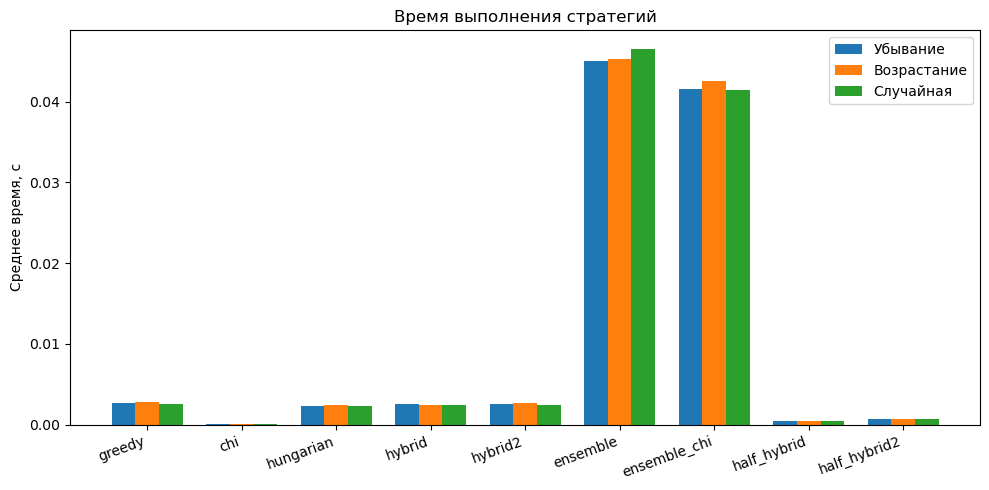

In [42]:
# Среднее время выполнения
fig, ax = plt.subplots(figsize=(10, 5))
for k, sname in enumerate(series_names):
    vals = [np.mean(all_stats[sname][s]['times']) for s in strat_labels]
    ax.bar(x + k * width, vals, width, label=sname)
ax.set_xticks(x + width)
ax.set_xticklabels(strat_labels, rotation=20, ha='right')
ax.set_ylabel('Среднее время, с')
ax.set_title('Время выполнения стратегий')
ax.legend()
plt.tight_layout()
plt.show()
